<hr>
<div style="background-color: lightgray; padding: 20px; color: black;">
<div>
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" style="float: right; margin-right: 30px;" width="200"/> 
<font size="6.5" color="8C3061"><b>Gaussian Markov Random Fields Priors</b></font> <br>
<font size="5.5" color="8C3061"><b>Problemas Inversos - Tarea 4 </b></font> 
</div>
<div style="text-align: left">  <br>
Edison David Serrano Cárdenas. <br>
MSc en Matemáticas Aplicadas <br>
CIMAT - Sede Guanajuato <br>
</div>

</div>
<hr>


In [1]:
import numpy as np
import scipy.stats as ss
from math import sqrt
import matplotlib.pyplot as plt
import pytwalk
import corner
import os
from scipy.stats import gaussian_kde

np.random.seed(14)

In [2]:
if not os.path.exists('./images'):
    os.makedirs('./images')

## <font color="8C3061" >**Definición de la clase**</font> 

In [3]:
class PoissonInverseProblem:
    def __init__(self,n:int=10,delta:float=0.1,samples:int=10000):
        """
        Initialize the Poisson inverse problem with a discretized operator.
        Parameters
        ----------
        n : int
            Number of discretization points.
        delta : float
            Regularization parameter.
        """
        self.n = n
        self.h = 1/(self.n)
        self.xx = np.linspace(0, 1, self.n+1)
        self.x = (self.xx[1:] + self.xx[:-1])/2
        self.y = (self.xx[1:] + self.xx[:-1])/2
        
        # Initialize the discretized operator
        self.A = np.zeros((self.n, self.n))
        for i in range(self.n):
            for j in range(self.n):
                if j<=i:
                    self.A[i, j] = self.h*self.y[j]*(1-self.x[i])
                else:
                    self.A[i, j] = self.h*self.x[i]*(1-self.y[j])
        
        u = 1/sqrt(3)
        self.lambda_inv = 1/6*u*(1-u)*(1+u)/100
        self.lambda_ = 1/(self.lambda_inv)
        self.delta = delta    
        self.data = self.create_data()
        
        self.samples = samples
        self.compute_theorical_estimates()
        
        
    def create_data(self)-> np.ndarray:
        """
        Create the data for the Poisson inverse problem.
        The data is generated by evaluating the discretized operator on a known function
        and adding Gaussian noise.
        Returns
        -------
        np.ndarray
            The generated data.
        """
        
        data = 1/6*self.x*(1-self.x)*(1+self.x)
        data = data + ss.norm.rvs(loc=0, scale=self.lambda_inv, size=self.n)
        return data
    
    def lprior(self, fy:np.ndarray)-> np.ndarray:
        """
        Compute the logarithm of the Gaussian Markov random field (GMRF) prior.
        Using the negative laplacian operator as the precision matrix.
        Parameters
        ----------
        fy : np.ndarray
            The field to compute the prior for.
        Returns
        -------
        np.ndarray
            The GMRF prior.
        """
        # Compute the finite difference of fy
        sum = 2*np.sum(fy**2)-2*np.sum(fy[1:]*fy[:-1])
        sum = -(1/2)*(self.delta/self.h**2)*sum
        return sum  
    
    def llikelihood(self, fy:np.ndarray)-> float:
        """
        Compute the logarithm of the likelihood function.
        The likelihood is assumed to be Gaussian with a known variance.
        Parameters
        ----------
        fy : np.ndarray
            The field to compute the likelihood for.
        Returns
        -------
        float
            The likelihood value.
        """
        
        # Compute the likelihood
        diff = self.A@fy - self.data
        sum = -(self.lambda_/2)*np.sum(diff**2)
        return sum
    
    def energy(self, fy:np.ndarray)-> float:
        """
        Compute the total energy of the system.
        The total energy is the sum of the prior and likelihood.
        Parameters
        ----------
        fy : np.ndarray
            The field to compute the energy for.
        Returns
        -------
        float
            The total energy value.
        """
        return -self.lprior(fy)  -self.llikelihood(fy)
    
    def support(self, fy:np.ndarray)-> np.ndarray:
        return np.all(fy >= 0)*np.all(fy <= 1)
        
    
    def run_mcmc(self):
        
        dist_mcmc = pytwalk.pytwalk(n=self.n, 
                                    U=self.energy,
                                    Supp = self.support,
                                    )
        
        
        self.x0     = np.ones(self.n)*0.5
        self.xp0    = np.ones(self.n)
        
        dist_mcmc.Run(T     =self.samples, 
                      x0    =self.x0, 
                      xp0   =self.xp0)
        
        return dist_mcmc
    
    def compute_theorical_estimates(self):
        """
        Compute the theoretical estimates for the Poisson inverse problem.
        The estimates are based on the known function and the discretized operator.
        Returns
        -------
        np.ndarray
            The theoretical estimates.
        """
        
        # Compute the theoretical estimates
        self.Q = 2*np.eye(self.n)
        for i in range(1,self.n):
            self.Q[i,i-1] = -1
            self.Q[i-1,i] = -1
        
        self.mu_theorical = self.lambda_*np.linalg.solve(self.lambda_*self.A.T@self.A+self.Q,self.A.T@self.data)

## <font color="8C3061" >**Generación de los Datos**</font> 

In [4]:
problem = PoissonInverseProblem(n=10,samples=100000)
noisy_data = problem.data

## <font color="8C3061" >**Muestrear la Posterior**</font> 

In [5]:
dist_mcmc = problem.run_mcmc()

pytwalk: Running the twalk to 100000 iterations .  Sun, 13 Apr 2025, 19:18:27.
       Finish in approx. 28 sec.
pytwalk:      69631 iterations so far. Finish in approx. 13 sec.


/home/usuario/Code/venv_gen/lib/python3.12/site-packages/pytwalk/pytwalk.py:657: RuntimeWarning: overflow encountered in exp
  A = exp((u - u_prop) + (W1 - W2))


pytwalk: finished, 100000 iterations.
Sun, 13 Apr 2025, 19:19:11.


Acceptance rates for the Walk, Traverse, Blow and Hop kernels:[0.38435809 0.09469133 0.1308642  0.46135266]
Global acceptance rate: 0.24091
AutoMaxlag: maxlag= 546.
Integrated Autocorrelation Time: 180, IAT/n:    18.0


180

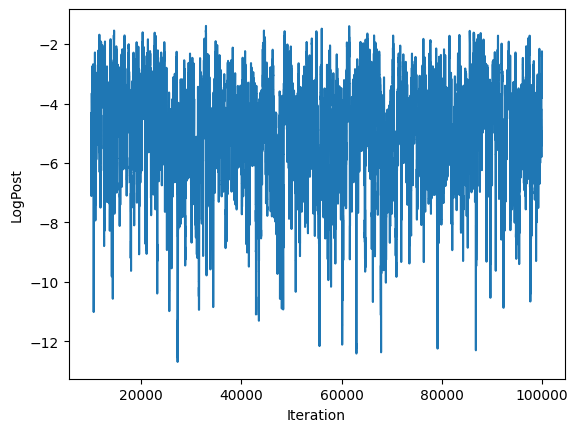

In [6]:
burnin = 10000
dist_mcmc.Ana(start=burnin)

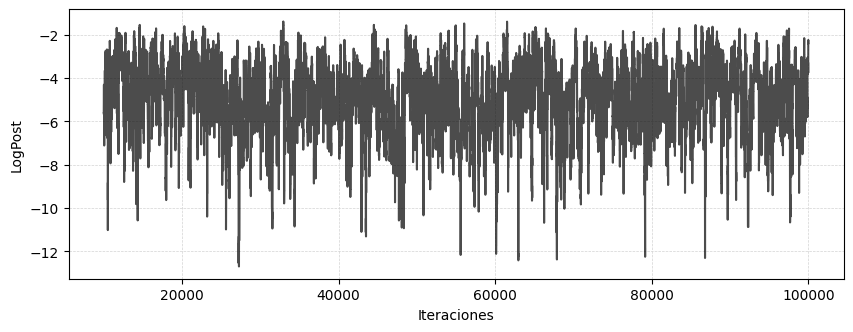

In [7]:
fig = plt.figure(figsize=(10, 3.5))
plt.plot(np.arange(burnin,problem.samples),-dist_mcmc.Output[burnin:,-1], color='black', alpha=0.7)
plt.grid(color="lightgray", linestyle='--', linewidth=0.5)
plt.xlabel('Iteraciones')
plt.ylabel('LogPost')
plt.savefig('./images/mcmc_energy.pdf', bbox_inches='tight')
plt.show()


In [8]:
mu = dist_mcmc.Output[burnin:,:-1][::180].mean(axis=0)
std = dist_mcmc.Output[burnin:,:-1][::180].std(axis=0)

sol_1 = np.quantile(dist_mcmc.Output[burnin:,:-1][::180],0.025,axis=0)
sol_2 = np.quantile(dist_mcmc.Output[burnin:,:-1][::180],0.975,axis=0)

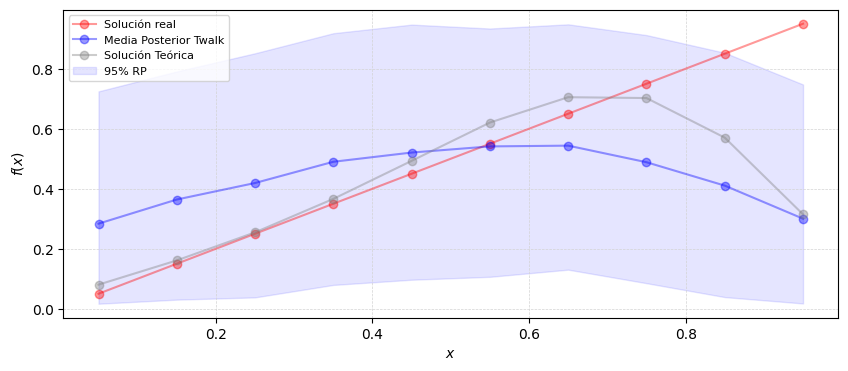

In [9]:
plt.figure(figsize=(10,4))

plt.plot(problem.y, problem.y, color='red',marker="o", alpha=0.4, label='Solución real')
plt.plot(problem.y, mu, color='blue',marker="o", alpha=0.4, label='Media Posterior Twalk')
plt.plot(problem.y, problem.mu_theorical, color='gray',marker="o", alpha=0.4, label='Solución Teórica')
plt.fill_between(problem.y,sol_1, sol_2, color='blue', alpha=0.1, label='95% RP')

plt.grid(color="lightgray", linestyle='--', linewidth=0.5)
plt.legend(loc='upper left', fontsize=8)
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.savefig('./images/fx_estimation.pdf', bbox_inches='tight')
plt.show()

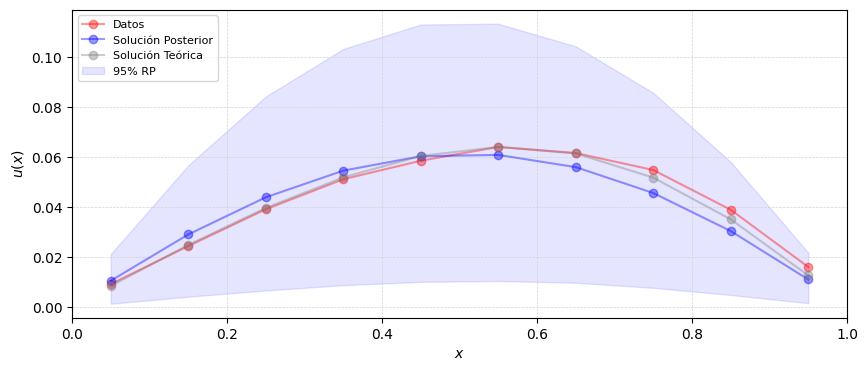

In [10]:
plt.figure(figsize=(10, 4))

plt.plot(problem.x,problem.data, color='red',marker="o", alpha=0.4, label='Datos')
plt.plot(problem.x,problem.A@mu, color='blue',marker="o", alpha=0.4, label='Solución Posterior')
plt.plot(problem.x,problem.A@problem.mu_theorical, color='gray',marker="o", alpha=0.4, label='Solución Teórica')
plt.fill_between(problem.x,problem.A@sol_1, problem.A@sol_2, color='blue', alpha=0.1, label='95% RP')
plt.grid(color="lightgray", linestyle='--', linewidth=0.5)
plt.xlabel(r'$x$')
plt.ylabel(r'$u(x)$')
plt.xlim(0,1)
plt.legend(loc='upper left', fontsize=8)
plt.savefig('./images/ux_estimation.pdf', bbox_inches='tight')
plt.show()

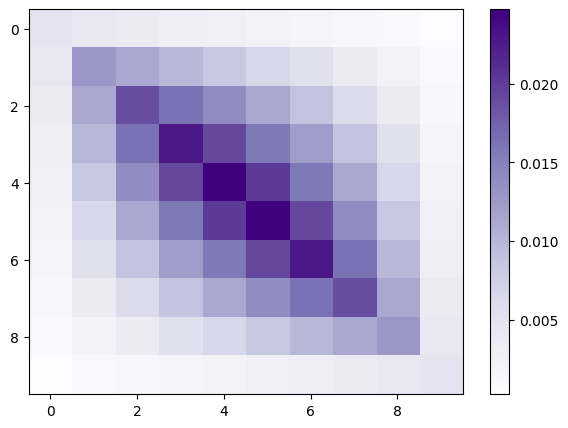

In [11]:
plt.figure(figsize=(7,5))
plt.imshow(problem.A, cmap='Purples', aspect='auto')
plt.colorbar()
plt.savefig('./images/A_matrix.pdf', bbox_inches='tight')   
plt.show()

## <font color="8C3061" >**Cálculo de la Constante de Normalización**</font> 

<font color="8C3061" >**Estimación Teórica**</font> 

In [12]:
alpha = (problem.lambda_/(2*np.pi))**(problem.n/2)
beta = (2*np.pi)**(-problem.n/2)*(problem.n+1)**(1/2)
c= np.log(alpha)+np.log(beta)

In [13]:
rho = alpha*beta*(2*np.pi)**(problem.n/2)
rho = rho*np.linalg.det(problem.lambda_*problem.A.T@problem.A+ problem.Q)**(-1/2)
rho = rho*np.exp(-1/2*problem.lambda_*(problem.data@problem.data-problem.mu_theorical@(problem.A.T@problem.data)))

In [14]:
print(f"Constante de normalización: {rho}")

Constante de normalización: 22398463559.80626


<font color="8C3061" >**Estimación Computacional**</font> 

In [15]:
gaussian_kde = gaussian_kde(dist_mcmc.Output[50000:,:-1].T)

In [16]:
N = 10000
fi = gaussian_kde.resample(N).T

In [17]:
a = np.apply_along_axis(lambda x: c-problem.energy(x)-gaussian_kde.logpdf(x), axis=1, arr=fi)

In [18]:
def logsumexp(a):
    a_max = np.max(a)
    return a_max + np.log(np.sum(np.exp(a - a_max)))

In [19]:
cte = logsumexp(a)

In [20]:
1/N+np.exp(cte)

np.float64(4564884288.632561)